# Inspect data products
What `heap.events.process_night()` writes (run by `process_pff.ipynb` or `pff_analysis.ipynb`), and how to load it
for further analysis:

```
<output_dir>/<YYYYMMDD>/<telescope>/
    processing.json              settings used
    <source>/<source>.npz        cleaned images + Hillas parameters, one row per frame
    <source>/calibrations.npz    pedestals, pedvars (per frame) and gain map (per night)
```

# Imports

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from heap import diagnostics as dg
from heap import events as ev
from heap.config import load_analysis_config
from heap.parameterize import CAMERA_CMAP, TAB10_COLORS
from heap.process_dataset import slugify

# Globals

In [2]:
CONFIG = Path("../configs/crab.yaml") # relative to analysis_tools/
cfg = load_analysis_config(CONFIG)

RAW_DATA_DIR = cfg["paths"]["raw_data_dir"]
OUTPUT_DIR = cfg["paths"]["output_dir"]
SOURCE = cfg["source"]["name"]
TELESCOPES = [info["name"] for info in cfg["telescopes"].values()]
REFERENCE = cfg["events"]["reference"]
COINC_WINDOW = cfg["events"]["coinc_window"]
WOBBLE_OFFSET = cfg["source"]["wobble_offset"] # deg, see heap.events.wobble_pointings()
POINTING_OVERRIDES = cfg["source"]["pointing_overrides"]
POINTING_CORRECTIONS = cfg["events"]["pointing_corrections"]
REL_TEL_EFFICIENCY = cfg["events"]["rel_tel_efficiency"]
MIN_NPIX = cfg["cuts"]["min_npix"]
COLORS = {name: TAB10_COLORS[i] for i, name in enumerate(sorted(TELESCOPES))}

DATE = None # night to inspect; None = first night with SOURCE
TELESCOPE = REFERENCE[0] # telescope to inspect

# Files
Every night, telescope and source in `OUTPUT_DIR` (see `heap.diagnostics.product_table()`).

In [3]:
products = dg.product_table(OUTPUT_DIR)
products.drop(columns="Settings")

,Date,Telescope,Source,Frames,Start,End,Hours,Rate,Cleaned,GainSource,MB
0,20260917,Fern,Crab,10528,2026-09-17 09:51:26+00:00,2026-09-17 12:06:08+00:00,2.25,1.30,0.863,other_night:20260918,130.6
1,20260917,Gattini,Crab,10942,2026-09-17 09:51:24+00:00,2026-09-17 12:06:07+00:00,2.25,1.35,0.764,other_night:20260918,135.8
2,20260917,Heli,Crab,10968,2026-09-17 09:51:24+00:00,2026-09-17 12:06:10+00:00,2.25,1.36,0.880,other_night:20260918,136.1
3,20260917,Winter,Crab,13797,2026-09-17 09:51:23+00:00,2026-09-17 12:06:05+00:00,2.25,1.71,0.751,other_night:20260918,171.2
4,20260918,Fern,Crab,10796,2026-09-18 10:54:59+00:00,2026-09-18 12:09:08+00:00,1.24,2.43,0.764,alt,134.0
5,20260918,Fern,MGRO_J2019_37,56570,2026-09-18 05:35:20+00:00,2026-09-18 08:26:25+00:00,2.85,5.51,0.344,alt,701.9
6,20260918,Gattini,Crab,11197,2026-09-18 10:54:21+00:00,2026-09-18 12:09:06+00:00,1.25,2.50,0.649,alt,138.9
7,20260918,Gattini,MGRO_J2019_37,69520,2026-09-18 05:35:21+00:00,2026-09-18 08:26:23+00:00,2.85,6.77,0.266,alt,862.6
8,20260918,Heli,Crab,11128,2026-09-18 10:55:16+00:00,2026-09-18 12:09:09+00:00,1.23,2.51,0.783,alt,138.1
9,20260918,Heli,MGRO_J2019_37,55620,2026-09-18 05:35:19+00:00,2026-09-18 08:26:27+00:00,2.85,5.42,0.371,alt,690.1


In [4]:
if DATE is None:
    DATE = products[products.Source == slugify(SOURCE, sep="_")].Date.iloc[0]
npz_path = ev.params_path(OUTPUT_DIR, DATE, TELESCOPE, SOURCE)
print(npz_path)
sorted(str(p.relative_to(OUTPUT_DIR)) for p in (OUTPUT_DIR / DATE / TELESCOPE).rglob("*"))

/home/nkorzoun/research/PANOSETI/data/processed/20260917/Winter/Crab/Crab.npz


['20260917/Winter/Crab',
 '20260917/Winter/Crab/Crab.npz',
 '20260917/Winter/Crab/calibrations.npz',
 '20260917/Winter/processing.json']

In [5]:
# settings the night was processed with; processing again with other settings needs REPROCESS or another output_dir
json.loads((OUTPUT_DIR / DATE / TELESCOPE / "processing.json").read_text())

{'data_product': 'dp_ph1024',
 'rate_cut': 3,
 'image_threshold': 4.0,
 'border_threshold': 2.0,
 'keep_brightest_island': True}

# Structure
Both npz files load as a `numpy.lib.npyio.NpzFile`: a read-only, dict-like map from key to numpy array (each array is
read from disk when its key is accessed). Every per-frame array has the same first axis `n`, frames in the same order
in both files, so row `i` of any key is the same frame.

In [6]:
npz = np.load(npz_path)
calib_npz = np.load(npz_path.parent / "calibrations.npz")
print(type(npz))
print(f"{npz_path.name}: {npz.files}")
print(f"calibrations.npz: {calib_npz.files}")

<class 'numpy.lib.npyio.NpzFile'>
Crab.npz: ['cleaned_images', 'N_pix', 'size', 'x_c', 'y_c', 's_xx', 's_yy', 's_xy', 'length', 'width', 'miss', 'distance', 'alpha', 'phi', 'Event', 'Timestamp']
calibrations.npz: ['pedestals', 'pedestal_variances', 'gain', 'gain_source', 'gain_caption']


In [7]:
dg.describe_npz(npz_path).style.format({"min": "{:.6g}", "max": "{:.6g}", "NaN": "{:.0f}"}, na_rep="")

,shape,dtype,min,max,NaN,description
key,,,,,,
cleaned_images,"(13797, 32, 32)",float32,0,4356.86,13946779,"(n, 32, 32) [frame, row, col]: (raw - pedestal) / gain, NaN where cleaning removed the pixel"
N_pix,"(13797,)",int64,0,750,0,"pixels left after cleaning (0 = nothing survived, Hillas parameters NaN)"
size,"(13797,)",float64,0,141764,0,"sum of the cleaned image (ADC, gain-corrected)"
x_c,"(13797,)",float64,-4.79531,4.79531,3439,"centroid x, along the columns (deg from camera center)"
y_c,"(13797,)",float64,-4.79531,4.79531,3439,"centroid y, along the rows (deg from camera center)"
s_xx,"(13797,)",float64,0,8.01966,3439,second central moment in x (deg^2)
s_yy,"(13797,)",float64,0,7.72371,3439,second central moment in y (deg^2)
s_xy,"(13797,)",float64,-0.96169,0.937808,3439,second central moment in xy (deg^2)
length,"(13797,)",float64,0.0721945,2.83672,3439,rms spread along the image axis (deg)


In [8]:
dg.describe_npz(npz_path.parent / "calibrations.npz").style.format({"min": "{:.6g}", "max": "{:.6g}", "NaN": "{:.0f}"}, na_rep="")

,shape,dtype,value,min,max,NaN,description
key,,,,,,,
pedestals,"(13797, 1024)",float32,,-3.72635,18.5589,0,"(n, 1024) [frame, row*32 + col]: pedestal (ADC), constant within each 600 s window, 0 if never set"
pedestal_variances,"(13797, 1024)",float32,,0,28.6668,0,"(n, 1024) [frame, row*32 + col]: pedvar (ADC), the cleaning threshold unit, 0 if never set"
gain,"(32, 32)",float32,,0.441167,2.48093,0,"(32, 32) [row, col]: relative gain for the whole night, mean 1"
gain_source,(),<U20,other_night:20260918,,,,"0-d string: which fallback made the gain map (own, alt, other_night:, flat)"
gain_caption,(),<U60,Reused from night 20260918 (no usable frame pair this night),,,,0-d string: the star fields the gain map came from


## One frame
Everything stored for one frame `i`. Images and the gain map are indexed `[row, col]` (row = y, col = x; plotted with
`origin="lower"`, and `extent=heap.parameterize.CAMERA_EXTENT` for degrees); pedestals and pedvars are flat per frame,
pixel `row*32 + col`. Hillas parameters are in degrees from the camera center (pixel `col` is at
`x = (col - 15.5) * PLATE_SCALE`, `PLATE_SCALE` = 0.309 deg/pixel).

In [9]:
i = int(np.flatnonzero(npz["N_pix"] >= 10)[0]) # first frame with at least 10 pixels left after cleaning
image = npz["cleaned_images"][i]
print(f"cleaned_images[{i}]: {type(image).__name__}, {image.dtype}, shape {image.shape}, {np.isfinite(image).sum()} finite pixels (. = NaN; row 0 printed first, so upside down relative to the plots)")
with np.printoptions(threshold=np.inf, linewidth=250, precision=0, suppress=True, nanstr="."):
    print(image)

cleaned_images[0]: ndarray, float32, shape (32, 32), 27 finite pixels (. = NaN; row 0 printed first, so upside down relative to the plots)
[[   .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .]
 [   .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .]
 [   .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .]
 [   .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .]
 [   .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .]
 [   .    .    .    .    .    .    .    .    .

In [10]:
# the same frame's Hillas parameters, one scalar per key
{key: npz[key][i].item() for key in npz.files if key != "cleaned_images"}

{'N_pix': 27,
 'size': 2788.012515369888,
 'x_c': 0.6986464492826563,
 'y_c': 1.369154395788769,
 's_xx': 0.15948441150090154,
 's_yy': 0.31574501853573245,
 's_xy': 0.16392263642844937,
 'length': 0.6474603032807007,
 'width': 0.23669513242206106,
 'miss': 0.13995193614537804,
 'distance': 1.5371046225299605,
 'alpha': 5.223961798629304,
 'phi': 57.74191445327764,
 'Event': 0,
 'Timestamp': 1789638683.859523}

In [11]:
# the same frame's calibrations, at its brightest pixel
row, col = np.unravel_index(np.nanargmax(image), image.shape)
pixel = row * 32 + col
print(f"cleaned_images[{i}][{row}, {col}] = {image[row, col]:.1f}")
print(f"pedestals[{i}][{pixel}] = {calib_npz['pedestals'][i][pixel]:.2f}   (= pedestals[{i}].reshape(32, 32)[{row}, {col}])")
print(f"pedestal_variances[{i}][{pixel}] = {calib_npz['pedestal_variances'][i][pixel]:.2f}")
print(f"gain[{row}, {col}] = {calib_npz['gain'][row, col]:.3f}")

cleaned_images[0][19, 17] = 426.7
pedestals[0][625] = 8.54   (= pedestals[0].reshape(32, 32)[19, 17])
pedestal_variances[0][625] = 19.27
gain[19, 17] = 0.896


In [12]:
# 0-d string arrays: .item() gives the str
print(repr(calib_npz["gain_source"]), "->", repr(calib_npz["gain_source"].item()))
print(repr(calib_npz["gain_caption"].item()))

array('other_night:20260918', dtype='<U20') -> 'other_night:20260918'
'Reused from night 20260918 (no usable frame pair this night)'


# Hillas parameters
`heap.diagnostics.load_products()` returns the Hillas parameters as a DataFrame,
the cleaned images and the calibrations, all one row per frame. Rows are every frame after the packet-loss and spike
cuts, in processing order (preflip runs, then postflip), not sorted by time; `Event` is the row index.

In [13]:
params, images, calib = dg.load_products(OUTPUT_DIR, DATE, TELESCOPE, SOURCE)
params.head()

,N_pix,size,x_c,y_c,s_xx,s_yy,s_xy,length,width,miss,distance,alpha,phi,Event,Timestamp
0,27,2788.012515,0.698646,1.369154,0.159484,0.315745,0.163923,0.647460,0.236695,0.139952,1.537105,5.223962,57.741914,0,1.789639e+09
1,8,1207.306042,-4.180961,4.659778,0.041549,0.029080,0.002389,0.204917,0.169227,5.342792,6.260508,58.584723,190.484597,1,1.789639e+09
2,14,2002.456139,-2.723934,3.220592,0.058976,0.090203,0.008837,0.304188,0.238010,3.454327,4.218060,54.978573,75.245521,2,1.789639e+09
3,16,1009.159295,-0.546211,-4.268043,0.067764,0.201786,-0.007552,0.449678,0.259498,0.784728,4.302852,10.508069,273.215170,3,1.789639e+09
4,28,2370.520757,-4.234671,0.242387,0.135834,0.324056,-0.140449,0.631672,0.246739,3.621830,4.241602,58.636503,118.087536,4,1.789639e+09


In [14]:
# load_products() returns the same arrays as a DataFrame + ndarray + NpzFile
print(type(params), type(images), images.shape, type(calib))
params.info()

<class 'pandas.core.frame.DataFrame'> <class 'numpy.ndarray'> (13797, 32, 32) <class 'numpy.lib.npyio.NpzFile'>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13797 entries, 0 to 13796
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   N_pix      13797 non-null  int64  
 1   size       13797 non-null  float64
 2   x_c        10358 non-null  float64
 3   y_c        10358 non-null  float64
 4   s_xx       10358 non-null  float64
 5   s_yy       10358 non-null  float64
 6   s_xy       10358 non-null  float64
 7   length     10358 non-null  float64
 8   width      10358 non-null  float64
 9   miss       10358 non-null  float64
 10  distance   10358 non-null  float64
 11  alpha      10358 non-null  float64
 12  phi        10358 non-null  float64
 13  Event      13797 non-null  int64  
 14  Timestamp  13797 non-null  float64
dtypes: float64(13), int64(2)
memory usage: 1.6 MB


In [15]:
params.describe()

,N_pix,size,x_c,y_c,s_xx,s_yy,s_xy,length,width,miss,distance,alpha,phi,Event,Timestamp
count,13797.000000,13797.000000,10358.000000,10358.000000,10358.000000,10358.000000,10358.000000,10358.000000,10358.000000,10358.000000,10358.000000,10358.000000,10358.000000,13797.000000,1.379700e+04
mean,13.144089,1607.828986,-0.255867,-0.100273,0.134233,0.136126,0.001842,0.416420,0.214884,2.402306,3.824114,43.804145,179.663549,6898.000000,1.789644e+09
std,17.846925,4085.786897,2.888990,2.831483,0.190251,0.190633,0.091450,0.204027,0.095691,1.525649,1.346783,25.901083,101.483031,3982.995167,2.295569e+03
min,0.000000,0.000000,-4.795313,-4.795313,0.000000,0.000000,-0.961690,0.072195,0.000000,0.000000,0.085417,0.000000,0.000000,0.000000,1.789639e+09
25%,2.000000,47.618764,-2.884469,-2.587986,0.044911,0.045768,-0.021693,0.279291,0.159531,1.082812,2.929050,21.272973,90.991455,3449.000000,1.789642e+09
50%,9.000000,621.632455,-0.440070,-0.246346,0.085518,0.088179,0.000000,0.380382,0.217597,2.273574,4.016850,43.470837,181.073837,6898.000000,1.789645e+09
75%,18.000000,1558.806301,2.218328,2.272882,0.157134,0.160609,0.023562,0.506415,0.267026,3.628493,4.786391,65.951188,266.870262,10347.000000,1.789646e+09
max,750.000000,141763.970245,4.795313,4.795313,8.019659,7.723715,0.937808,2.836716,2.774241,6.604234,6.750839,89.984168,360.000000,13796.000000,1.789647e+09


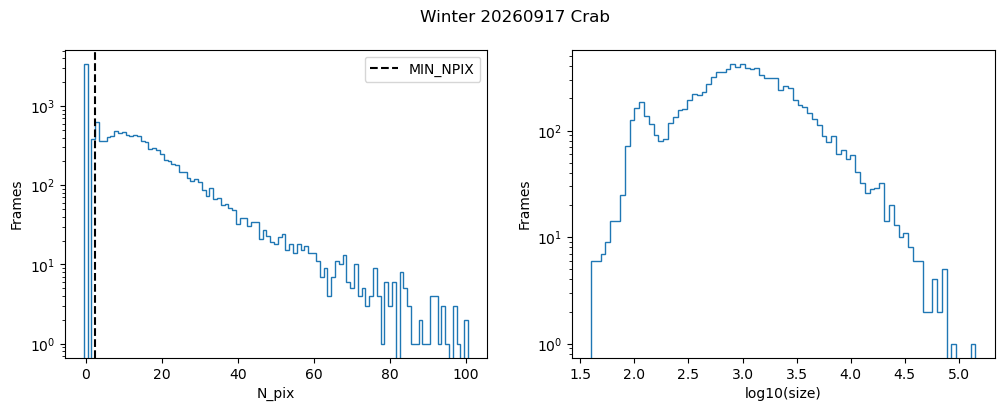

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].hist(params.N_pix, bins=np.arange(0, 102) - 0.5, histtype="step") # N_pix > 100 not shown
axs[0].axvline(MIN_NPIX - 0.5, color="k", ls="--", label="MIN_NPIX")
axs[0].set(yscale="log", xlabel="N_pix", ylabel="Frames")
axs[0].legend()
axs[1].hist(np.log10(params["size"][params.N_pix > 0]), bins=80, histtype="step")
axs[1].set(yscale="log", xlabel="log10(size)", ylabel="Frames")
fig.suptitle(f"{TELESCOPE} {DATE} {SOURCE}")
plt.show()

# Images
Cleaned images are pedestal-subtracted and gain-corrected, `(raw - pedestal) / gain`, with the pixels cleaning
removed set to NaN. Raw images aren't saved. Run the cell again for another random set.

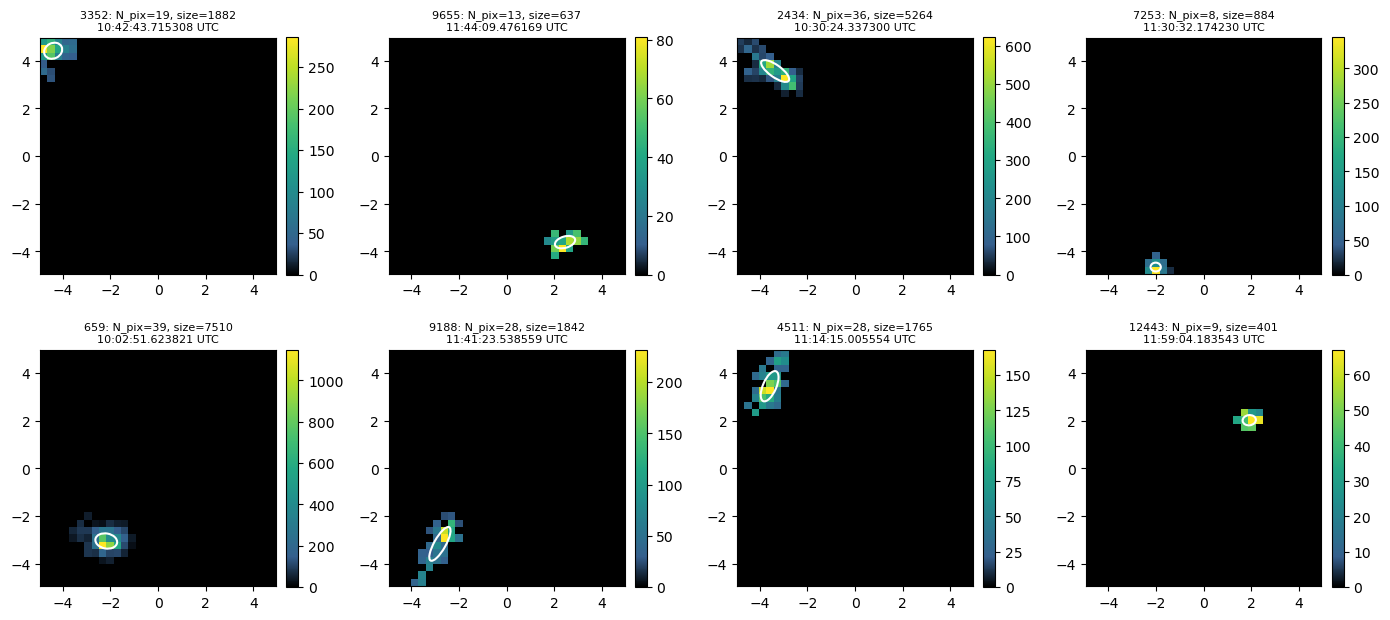

In [17]:
idx = np.random.default_rng().choice(np.flatnonzero(params.N_pix >= MIN_NPIX), size=8, replace=False)
dg.plot_image_grid(params, images, idx)
plt.show()

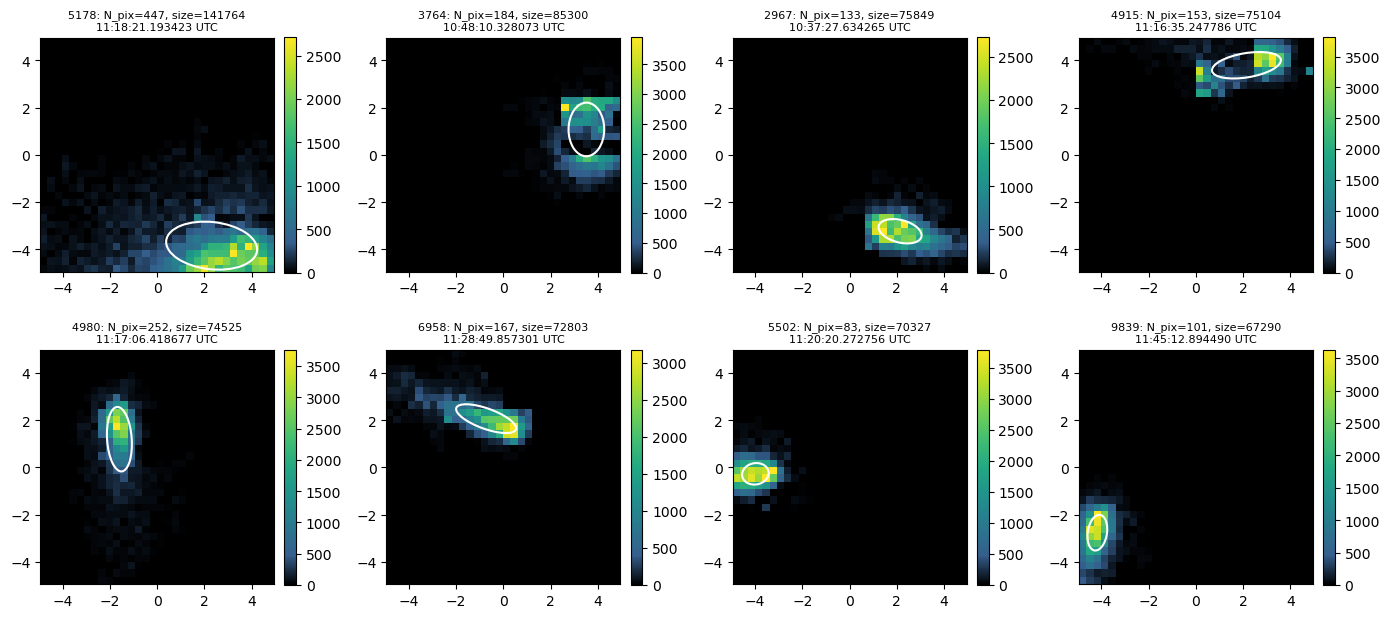

In [18]:
# brightest images
dg.plot_image_grid(params, images, params.nlargest(8, "size").index)
plt.show()

# Calibrations
`pedestals` and `pedestal_variances` are per frame (same rows as `params`, constant within each 600 s window); `gain`
is one (32, 32) map for the night, made as `gain_caption` says.

other_night:20260918 - Reused from night 20260918 (no usable frame pair this night)


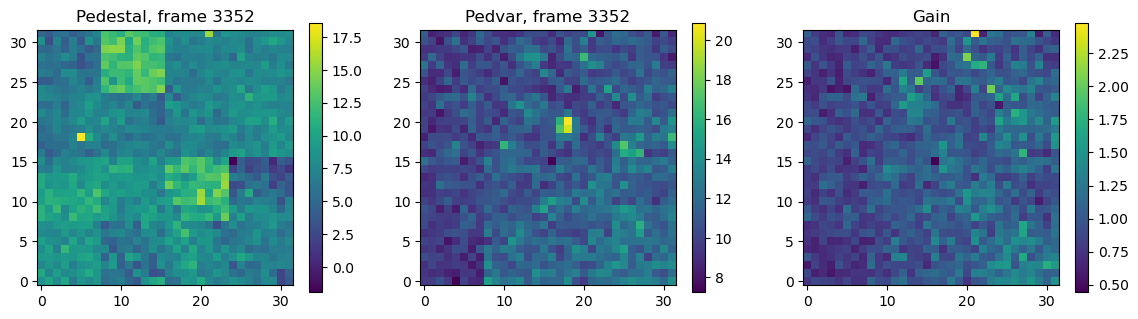

In [19]:
print(calib["gain_source"], "-", calib["gain_caption"])
i = idx[0]
fig, axs = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, (values, label) in zip(axs, [(calib["pedestals"][i], "Pedestal"), (calib["pedestal_variances"][i], "Pedvar"), (calib["gain"], "Gain")]):
    fig.colorbar(ax.imshow(values.reshape(32, 32), origin="lower"), ax=ax)
    ax.set_title(f"{label}, frame {i}" if label != "Gain" else label)
plt.show()

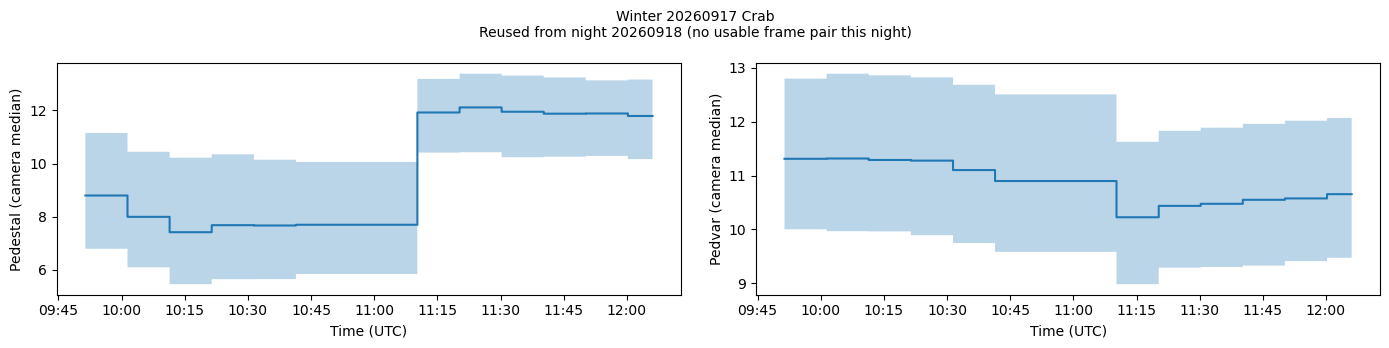

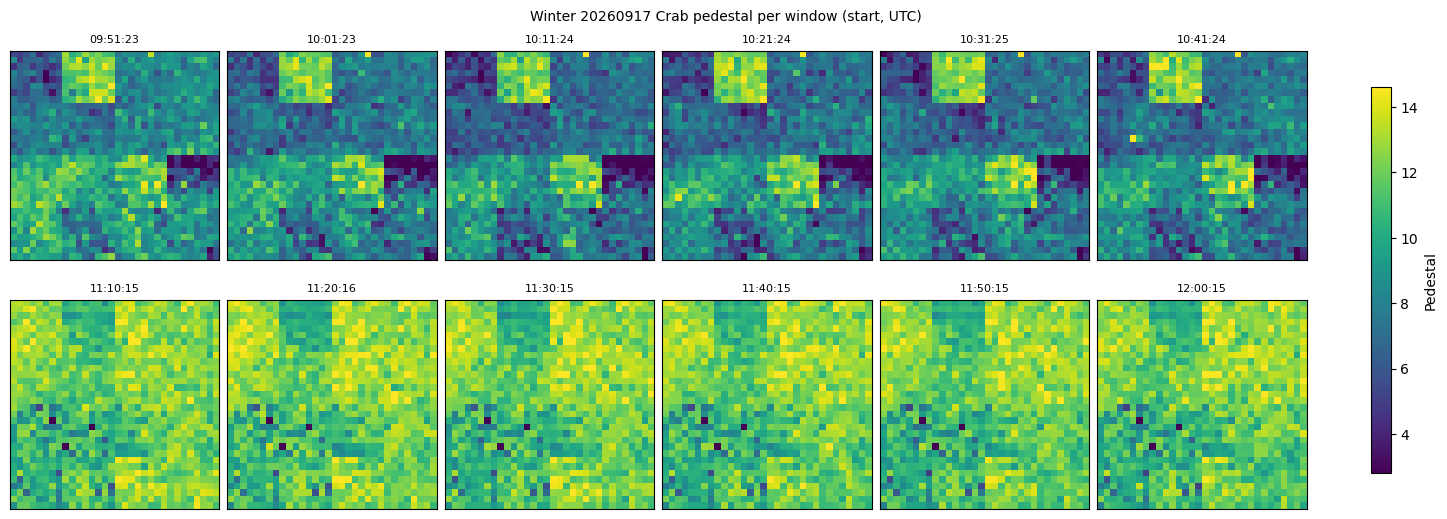

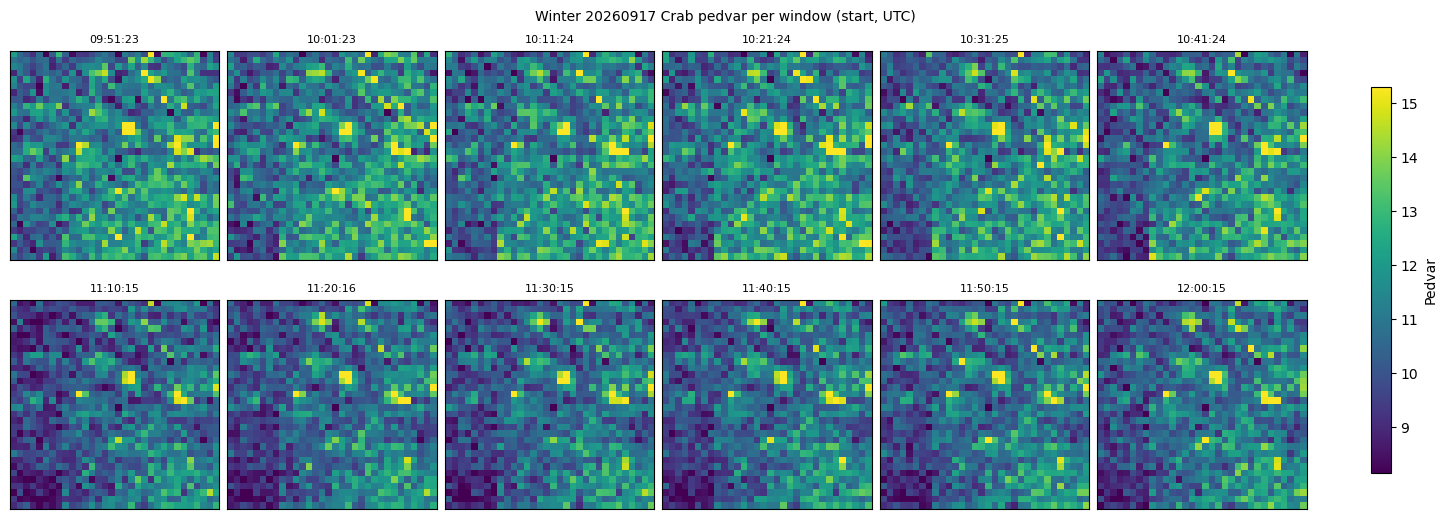

In [20]:
dg.plot_calibrations(params, calib, f"{TELESCOPE} {DATE} {SOURCE}")
dg.plot_calibration_windows(params, calib, f"{TELESCOPE} {DATE} {SOURCE}")
plt.show()

# Camera coordinates
`heap.events.load_camera_frame()` keeps the npz's Hillas columns, sorts by time, adds each frame's
flip side and run (from the raw `hk.pff`, so `RAW_DATA_DIR` is still needed) and rotates postflip images to the preflip orientation.
`ImageIndex` is the row in `images`.

In [21]:
runs = ev.source_runs(RAW_DATA_DIR / DATE, TELESCOPE, SOURCE)
frame = ev.load_camera_frame(npz_path, TELESCOPE, runs)
frame.head()

,ImageIndex,Telescope,Timestamp,FlipSide,Run,x_c,y_c,phi,size,N_pix,length,width,miss,distance,alpha,x_shift,y_shift
0,0,Winter,1.789639e+09,preflip,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,0.698646,1.369154,57.741914,2788.012515,27,0.647460,0.236695,0.139952,1.537105,5.223962,0.0,0.0
1,1,Winter,1.789639e+09,preflip,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,-4.180961,4.659778,190.484597,1207.306042,8,0.204917,0.169227,5.342792,6.260508,58.584723,0.0,0.0
2,2,Winter,1.789639e+09,preflip,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,-2.723934,3.220592,75.245521,2002.456139,14,0.304188,0.238010,3.454327,4.218060,54.978573,0.0,0.0
3,3,Winter,1.789639e+09,preflip,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,-0.546211,-4.268043,273.215170,1009.159295,16,0.449678,0.259498,0.784728,4.302852,10.508069,0.0,0.0
4,4,Winter,1.789639e+09,preflip,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,-4.234671,0.242387,118.087536,2370.520757,28,0.631672,0.246739,3.621830,4.241602,58.636503,0.0,0.0


In [22]:
frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13797 entries, 0 to 13796
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ImageIndex  13797 non-null  int64  
 1   Telescope   13797 non-null  object 
 2   Timestamp   13797 non-null  float64
 3   FlipSide    13797 non-null  object 
 4   Run         13797 non-null  object 
 5   x_c         10358 non-null  float64
 6   y_c         10358 non-null  float64
 7   phi         10358 non-null  float64
 8   size        13797 non-null  float64
 9   N_pix       13797 non-null  int64  
 10  length      10358 non-null  float64
 11  width       10358 non-null  float64
 12  miss        10358 non-null  float64
 13  distance    10358 non-null  float64
 14  alpha       10358 non-null  float64
 15  x_shift     10358 non-null  float64
 16  y_shift     10358 non-null  float64
dtypes: float64(12), int64(2), object(3)
memory usage: 1.8+ MB


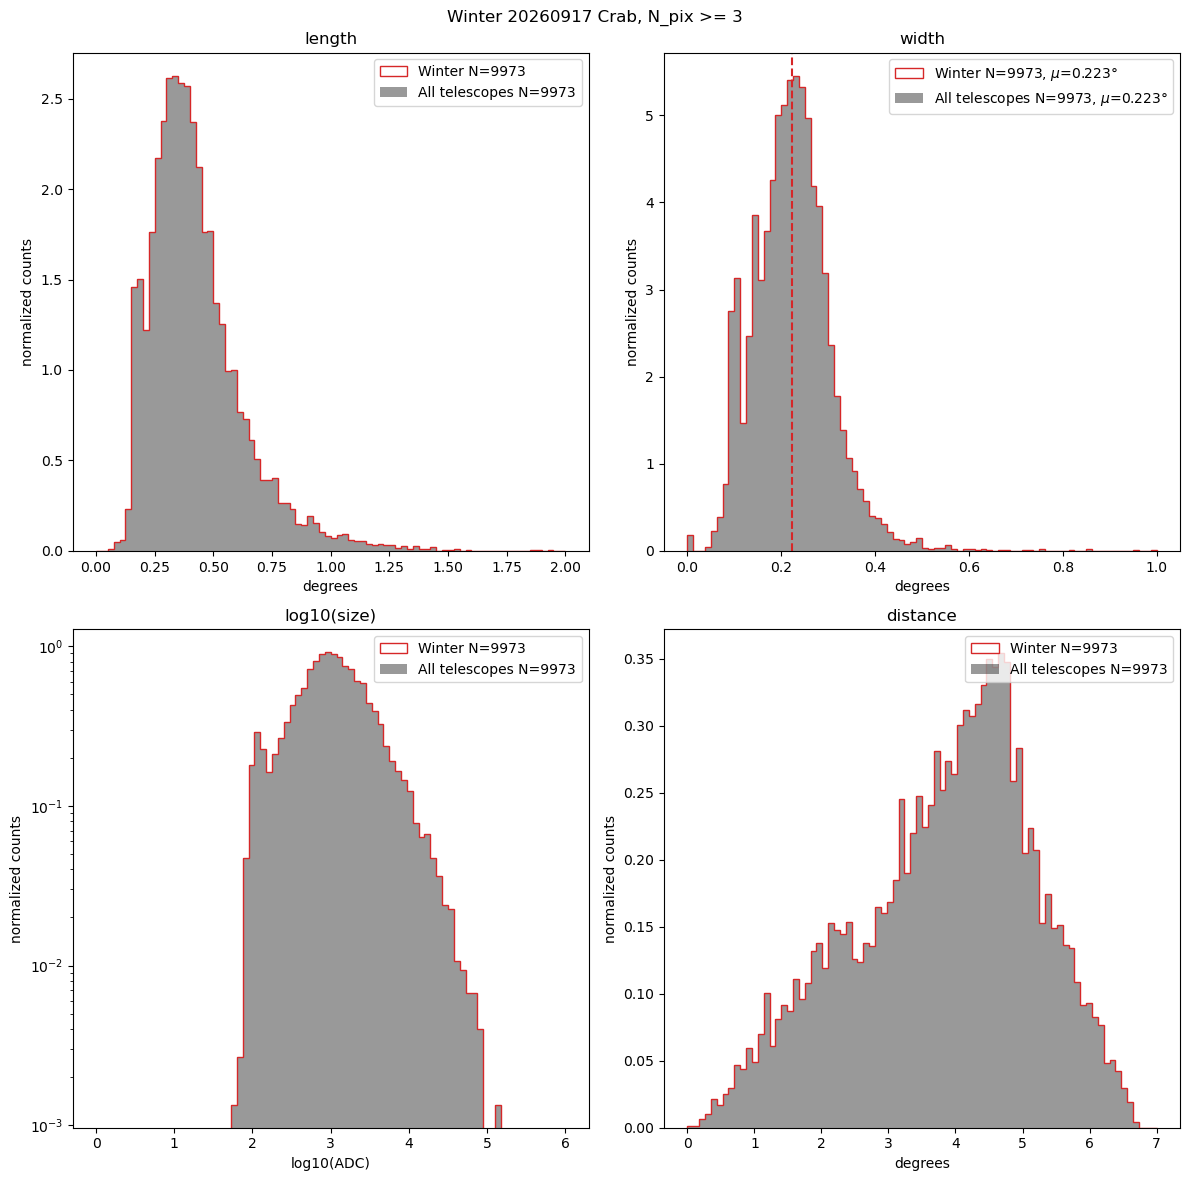

In [23]:
ev.plot_hillas(frame[frame.N_pix >= MIN_NPIX], f"{TELESCOPE} {DATE} {SOURCE}, N_pix >= {MIN_NPIX}", colors=COLORS)
plt.show()

# Array events
`heap.events.build_array_events()` does the above for every telescope, keeps the runs with a pointing (each run's commanded wobble
position, shared by every telescope, see `heap.events.wobble_pointings()`), corrects timestamps against the timing reference (in each 120 s of each run, the first
telescope in `REFERENCE` with data), and matches images within `COINC_WINDOW` into events, adding each event's `Date` and `Run`. Runs whose wobble can't be told from hk and have no
`POINTING_OVERRIDES` entry are left out, with a printout. This is `pff_analysis.ipynb`'s
starting point (its `df`) with every telescope, before any cuts (including `cuts.telescopes`).

In [24]:
events, _ = ev.build_array_events(OUTPUT_DIR, RAW_DATA_DIR / DATE, DATE, SOURCE, TELESCOPES, REFERENCE, window=COINC_WINDOW, wobble_offset=WOBBLE_OFFSET,
                                  pointing_corrections=POINTING_CORRECTIONS, rel_tel_efficiency=REL_TEL_EFFICIENCY,
                                  pointing_overrides=POINTING_OVERRIDES)
events.head(10)

obs_Palomar.start_2026-09-17T09:50:18Z.runtype_eng-dual.pffd, 09:51:23-10:51:23 UTC: timing reference Winter; Heli 3357, Fern 3076, Winter 3972, Gattini 3189 images
Winter-Heli, run 09:50:18, 09:51:23-10:51:23 UTC timing offset: RMS=  6e-05 s, std= 5e-05 s
Winter-Heli, run 09:50:18, 09:51:23-10:51:23 UTC corrected offset: RMS=  0.0 s, std= 0.0 s
Winter-Fern, run 09:50:18, 09:51:23-10:51:23 UTC timing offset: RMS=  7e-05 s, std= 5e-05 s
Winter-Fern, run 09:50:18, 09:51:23-10:51:23 UTC corrected offset: RMS=  0.0 s, std= 0.0 s
Winter-Gattini, run 09:50:18, 09:51:23-10:51:23 UTC timing offset: RMS=  0.00036 s, std= 0.00035 s
Winter-Gattini, run 09:50:18, 09:51:23-10:51:23 UTC corrected offset: RMS=  0.0 s, std= 0.0 s
Heli-Fern within 0.001s: 1612/3353 Heli events (48.1%) and 1612/3076 Fern events (52.4%) coincident, 1614 pairs
Heli-Winter within 0.001s: 1481/3353 Heli events (44.2%) and 1483/3972 Winter events (37.3%) coincident, 1484 pairs
Heli-Gattini within 0.001s: 216/3353 Heli events

,Event,Date,Run,ImageIndex,Telescope,Timestamp,FlipSide,x_c,y_c,phi,size,N_pix,length,width,miss,distance,alpha,x_shift,y_shift
0,0,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,0,Fern,1.789639e+09,preflip,-3.540731,3.924974,128.664679,2214.582265,20,0.411947,0.273624,0.312486,5.286038,3.389037,0.0,0.0
1,0,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,4,Heli,1.789639e+09,preflip,-3.059010,3.762411,150.115798,2348.941153,17,0.399190,0.210049,1.737991,4.849050,21.003127,0.0,0.0
2,0,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,2,Winter,1.789639e+09,preflip,-2.723934,3.220592,75.245521,2002.456139,14,0.304188,0.238010,3.454327,4.218060,54.978573,0.0,0.0
3,1,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,1,Fern,1.789639e+09,preflip,-1.305843,-4.259367,284.144989,1814.154079,18,0.567324,0.210577,2.307139,4.455046,31.189554,0.0,0.0
4,1,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,5,Heli,1.789639e+09,preflip,-1.118175,-4.405495,301.575273,3139.545703,25,0.530072,0.308519,3.259430,4.545184,45.816985,0.0,0.0
5,1,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,3,Winter,1.789639e+09,preflip,-0.546211,-4.268043,273.215170,1009.159295,16,0.449678,0.259498,0.784728,4.302852,10.508069,0.0,0.0
6,2,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,3,Fern,1.789639e+09,preflip,1.471767,4.290243,92.640030,969.828937,12,0.290390,0.221896,1.667817,4.535668,21.574549,0.0,0.0
7,2,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,3,Gattini,1.789639e+09,preflip,2.242657,2.244917,320.853010,3076.537976,24,0.332356,0.307594,3.156814,3.173194,84.175849,0.0,0.0
8,2,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,9,Heli,1.789639e+09,preflip,1.908477,4.083288,74.092250,2166.447330,19,0.406838,0.240346,0.716205,4.507275,9.143045,0.0,0.0
9,2,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,7,Winter,1.789639e+09,preflip,0.519261,3.459777,68.070168,1545.053872,18,0.503589,0.273479,0.810437,3.498527,13.394292,0.0,0.0


`events` is in long format: one row per telescope image, with `Event` grouping the images of one shower
(2+ telescopes). `ImageIndex` is the image's row in its own telescope's npz files.

In [25]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15264 entries, 0 to 15263
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Event       15264 non-null  int64  
 1   Date        15264 non-null  object 
 2   Run         15264 non-null  object 
 3   ImageIndex  15264 non-null  int64  
 4   Telescope   15264 non-null  object 
 5   Timestamp   15264 non-null  float64
 6   FlipSide    15264 non-null  object 
 7   x_c         15127 non-null  float64
 8   y_c         15127 non-null  float64
 9   phi         15127 non-null  float64
 10  size        15264 non-null  float64
 11  N_pix       15264 non-null  int64  
 12  length      15127 non-null  float64
 13  width       15127 non-null  float64
 14  miss        15127 non-null  float64
 15  distance    15127 non-null  float64
 16  alpha       15127 non-null  float64
 17  x_shift     15127 non-null  float64
 18  y_shift     15127 non-null  float64
dtypes: float64(12), int64(3),

In [26]:
e = events.Event.iloc[0]
event_rows = events[events.Event == e]
display(event_rows)
# each image back in its telescope's npz: same size as in the table (size may be divided by rel_tel_efficiency)
for _, image_row in event_rows.iterrows():
    tel_npz = np.load(ev.params_path(OUTPUT_DIR, DATE, image_row.Telescope, SOURCE))
    print(image_row.Telescope, image_row.ImageIndex, tel_npz["size"][image_row.ImageIndex], tel_npz["Timestamp"][image_row.ImageIndex])

,Event,Date,Run,ImageIndex,Telescope,Timestamp,FlipSide,x_c,y_c,phi,size,N_pix,length,width,miss,distance,alpha,x_shift,y_shift
0,0,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,0,Fern,1.789639e+09,preflip,-3.540731,3.924974,128.664679,2214.582265,20,0.411947,0.273624,0.312486,5.286038,3.389037,0.0,0.0
1,0,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,4,Heli,1.789639e+09,preflip,-3.059010,3.762411,150.115798,2348.941153,17,0.399190,0.210049,1.737991,4.849050,21.003127,0.0,0.0
2,0,20260917,obs_Palomar.start_2026-09-17T09:50:18Z.runtype...,2,Winter,1.789639e+09,preflip,-2.723934,3.220592,75.245521,2002.456139,14,0.304188,0.238010,3.454327,4.218060,54.978573,0.0,0.0


Fern 0 2214.5822654502913 1789638686.190306
Heli 4 2348.9411529531626 1789638686.190149
Winter 2 2002.4561394013945 1789638686.19029


In [27]:
events.groupby("Event").Telescope.agg(lambda t: " + ".join(sorted(t))).value_counts()

Telescope
Fern + Heli + Winter              2181
Fern + Heli                       1900
Heli + Winter                      898
Fern + Winter                      720
Fern + Gattini + Heli + Winter     191
Gattini + Winter                   144
Gattini + Heli                     107
Gattini + Heli + Winter            103
Fern + Gattini                      22
Fern + Gattini + Heli               18
Fern + Gattini + Winter              4
Name: count, dtype: int64

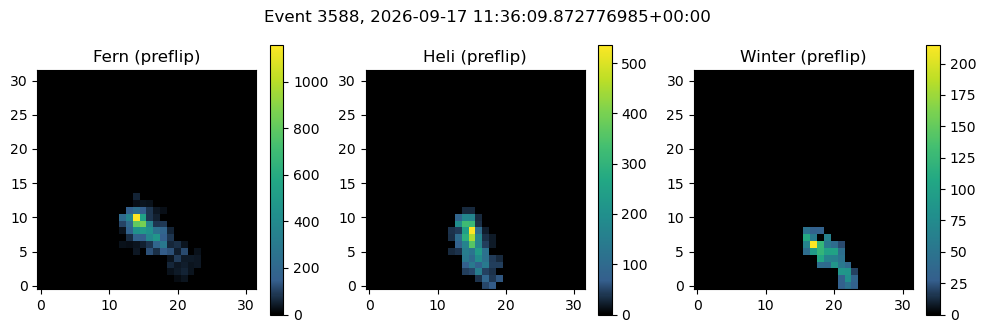

In [28]:
# one event's images, each from its own telescope's npz
event = events[events.Event == events.Event.sample(1).iloc[0]]
fig, axs = plt.subplots(1, len(event), figsize=(4*len(event), 3.5), squeeze=False)
for ax, (_, image) in zip(axs[0], event.iterrows()):
    tel_images = dg.load_products(OUTPUT_DIR, DATE, image.Telescope, SOURCE)[1]
    fig.colorbar(ax.imshow(tel_images[image.ImageIndex], origin="lower", cmap=CAMERA_CMAP, vmin=0), ax=ax)
    ax.set_title(f"{image.Telescope} ({image.FlipSide})")
fig.suptitle(f"Event {event.Event.iloc[0]}, {pd.to_datetime(event.Timestamp.min(), unit='s', utc=True)}")
plt.show()

To keep events (or `pff_analysis.ipynb`'s `array`/`directions`) for later, save them, e.g.
`events.to_csv(OUTPUT_DIR / DATE / "events.csv", index=False)`.